In [694]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import csv, json
from sklearn.metrics import root_mean_squared_error,mean_squared_error
import numpy as np


In [696]:
# ls ../RawData_EnergyLogger/5-dec/homemade_script_energylogger_overhead_stressng/

In [698]:
input_directory = '../RawData_EnergyLogger/5-dec/homemade_script_energylogger_overhead_stressng/'
output_directory = '../Results/'

In [704]:
df_test = pd.read_csv('../RawData_EnergyLogger/5-dec/homemade_script_energylogger_overhead_stressng/pmic_log_0_0.01s_20251027_223113.csv',header=0)
print(df_test.columns)
display(df_test)

Index(['duration_s', 'active', '3V7_WL_SW_A current(0)',
       '3V3_SYS_A current(1)', '1V8_SYS_A current(2)', 'DDR_VDD2_A current(3)',
       'DDR_VDDQ_A current(4)', '1V1_SYS_A current(5)', '0V8_SW_A current(6)',
       'VDD_CORE_A current(7)', '3V3_DAC_A current(17)',
       '3V3_ADC_A current(18)', '0V8_AON_A current(16)', 'HDMI_A current(22)',
       '3V7_WL_SW_V volt(8)', '3V3_SYS_V volt(9)', '1V8_SYS_V volt(10)',
       'DDR_VDD2_V volt(11)', 'DDR_VDDQ_V volt(12)', '1V1_SYS_V volt(13)',
       '0V8_SW_V volt(14)', 'VDD_CORE_V volt(15)', '3V3_DAC_V volt(20)',
       '3V3_ADC_V volt(21)', '0V8_AON_V volt(19)', 'HDMI_V volt(23)',
       'EXT5V_V volt(24)', 'BATT_V volt(25)'],
      dtype='object')


,duration_s,active,3V7_WL_SW_A current(0),3V3_SYS_A current(1),1V8_SYS_A current(2),DDR_VDD2_A current(3),DDR_VDDQ_A current(4),1V1_SYS_A current(5),0V8_SW_A current(6),VDD_CORE_A current(7),...,DDR_VDDQ_V volt(12),1V1_SYS_V volt(13),0V8_SW_V volt(14),VDD_CORE_V volt(15),3V3_DAC_V volt(20),3V3_ADC_V volt(21),0V8_AON_V volt(19),HDMI_V volt(23),EXT5V_V volt(24),BATT_V volt(25)
0,0.000001,0,0.0,0.192258,0.145414,0.0,0.0,0.197138,0.279116,0.54473,...,0.615018,1.102197,0.800732,0.749987,3.303110,3.299447,0.798241,4.92450,4.93522,0.004274
1,0.024180,0,0.0,0.196162,0.146390,0.0,0.0,0.179571,0.280092,0.53580,...,0.615750,1.102929,0.798900,0.749718,3.305857,3.300363,0.797948,4.92852,4.94192,0.004274
2,0.048338,0,0.0,0.196162,0.146390,0.0,0.0,0.189330,0.278140,2.18785,...,0.615384,1.101098,0.799633,0.749450,3.305857,3.299447,0.798241,4.92584,4.93790,0.004274
3,0.072470,0,0.0,0.197138,0.145414,0.0,0.0,0.178595,0.280092,0.53580,...,0.615018,1.101098,0.801464,0.749987,3.304942,3.300363,0.797655,4.92450,4.93522,0.004274
4,0.096634,0,0.0,0.195186,0.147365,0.0,0.0,0.177619,0.280092,0.12502,...,0.616483,1.102929,0.799633,0.749181,3.304942,3.301279,0.797948,4.92450,4.92986,0.004274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3412,82.397851,0,0.0,0.198114,0.144438,0.0,0.0,0.179571,0.279116,0.54473,...,0.615384,1.104761,0.799633,0.749450,3.305857,3.300363,0.797948,4.92584,4.92986,0.003419
3413,82.421966,0,0.0,0.199090,0.147365,0.0,0.0,0.179571,0.278140,0.53580,...,0.616483,1.105127,0.800365,0.748913,3.303110,3.299447,0.797948,4.92450,4.93522,0.003419
3414,82.446078,0,0.0,0.203969,0.147365,0.0,0.0,0.177619,0.281068,0.54473,...,0.616483,1.102197,0.799633,0.749987,3.304942,3.300363,0.797948,4.92852,4.93120,0.003419
3415,82.470165,0,0.0,0.200066,0.144438,0.0,0.0,0.179571,0.281068,0.53580,...,0.613919,1.100732,0.800365,0.749450,3.303110,3.299447,0.798241,4.92450,4.93924,0.004274


In [706]:
df_test_active = df_test[df_test['active']==1]
df_test_active['duration_s'].max()-df_test_active['duration_s'].min()

79.97905399999999

In [708]:

filename = 'pmic_log_0_1s_20251027_224819.csv'

pattern = re.compile(r"pmic_log_(?P<load>\d+)_(?P<period>[0-9.]+)s_\d{8}_\d{6}\.csv$")
m = pattern.search(filename)  # use search if there's a path or extra stuff
if m:
    load = int(m.group(1))       # 40
    period_s = float(m.group(2)) # 0.05


print(load, period_s)

0 1.0


In [710]:
#import all the CSV files

# (a) Read from row 3 and on into df and calculate energy consumption
# (b) Read the first two lines with meta data, add the calculated energy consumption and concat to the existing
ID = 0
list_of_metadataframes = []
list_of_dataframes = []
energy_columns= ['3V7_WL_SW','3V3_SYS','1V8_SYS','DDR_VDD2','DDR_VDDQ',
                        '1V1_SYS','0V8_SW','VDD_CORE','3V3_DAC','3V3_ADC','0V8_AON','HDMI']

for input_file in os.listdir(input_directory):
    file_path = input_directory+'/'
    file_name = os.path.basename(input_file)
    #print(file_name)
    
    load = 200
    period = 200.0
    
    
    
    if file_name.endswith('.csv'):
        pattern = re.compile(r"pmic_log_(\d+)_([0-9]*\.?[0-9]+)s_")
        m = pattern.search(file_name)  # use search if there's a path or extra stuff
        if m:
            load = int(m.group(1))       # find the CPU load from the file name
            period = float(m.group(2))   # find the requested period from the file name
        #print(file_name,load,period)
        
        df = pd.read_csv(file_path+file_name,header=0) # read csv file into Data Frame
        df['load'] = load
        df['period'] = period
        df['ID'] = ID
        # compute the power dissipation for each of the rails 
        df['3V7_WL_SW']= df['3V7_WL_SW_A current(0)']*df['3V7_WL_SW_V volt(8)']
        df['3V3_SYS']= df['3V3_SYS_A current(1)']*df['3V3_SYS_V volt(9)']
        df['1V8_SYS']= df['1V8_SYS_A current(2)']*df['1V8_SYS_V volt(10)']
        df['DDR_VDD2']= df['DDR_VDD2_A current(3)']*df['DDR_VDD2_V volt(11)']
        df['DDR_VDDQ']= df['DDR_VDDQ_A current(4)']*df['DDR_VDDQ_V volt(12)']
        df['1V1_SYS']= df['1V1_SYS_A current(5)']*df['1V1_SYS_V volt(13)']
        df['0V8_SW']= df['0V8_SW_A current(6)']*df['0V8_SW_V volt(14)']
        df['VDD_CORE']= df['VDD_CORE_A current(7)']*df['VDD_CORE_V volt(15)']
        df['3V3_DAC']= df['3V3_DAC_A current(17)']*df['3V3_DAC_V volt(20)']
        df['3V3_ADC']= df['3V3_ADC_A current(18)']*df['3V3_ADC_V volt(21)']
        df['0V8_AON']= df['0V8_AON_A current(16)']*df['0V8_AON_V volt(19)']
        df['HDMI']= df['HDMI_A current(22)']*df['HDMI_V volt(23)']
        
        df_active = df[df['active']==1]
        duration = df_active['duration_s'].max()-df_active['duration_s'].min()
        
        # computer the total energy consumed for each power channel and save this into a meta frame
        df_summary = pd.DataFrame.from_dict(data={'ID':[ID], 'load':[load], 'period':[period], 'filename':[filename], 'duration': [duration]})  
        
        for channel in power_columns:
            # When we want to compute the energy consumption for the different channels
            x = df['duration_s'] # timesteps
            y = df[channel] # Power Dissipation for channel in Watt 
            y_int = integrate.cumulative_trapezoid(y, x, initial=0) #accumulated area under the curve for each timestemp
            energy = y_int[-1]  #area under the curve
            df_summary[channel]= [energy]
            
        df["dt_to_next"] = df["duration_s"].shift(-1) - df["duration_s"]
        df['diff'] = df["dt_to_next"]-df["period"]
        df = df.drop(columns=["dt_to_next"])
        list_of_metadataframes.append(df_summary)
        list_of_dataframes.append(df)
        ID = ID + 1


In [711]:

dfs = pd.concat(list_of_metadataframes)
df_powers = pd.concat(list_of_dataframes)
df_powers= df_powers.reset_index(drop=True)
dfs= dfs.reset_index(drop=True)

In [714]:
 df_powers = df_powers[df_powers['active']==1]

In [716]:
dfs.head(5)

,ID,load,period,filename,duration,3V7_WL_SW,3V3_SYS,1V8_SYS,DDR_VDD2,DDR_VDDQ,1V1_SYS,0V8_SW,VDD_CORE,3V3_DAC,3V3_ADC,0V8_AON,HDMI
0,0,40,0.02,pmic_log_0_1s_20251027_224819.csv,79.988601,0.059100,54.456447,22.768062,0.048884,0.002104,16.502727,18.543509,92.813460,0.045866,0.141180,0.218236,6.429707
1,1,0,0.05,pmic_log_0_1s_20251027_224819.csv,79.960689,0.018105,54.123822,21.686807,0.002278,0.000000,16.413142,18.434590,33.512278,0.048573,0.156587,0.214069,6.788918
2,2,0,0.01,pmic_log_0_1s_20251027_224819.csv,79.970523,0.024908,54.150361,21.716967,0.004669,0.000203,16.432699,18.441221,34.873584,0.046166,0.152944,0.214068,6.758719
3,3,80,0.02,pmic_log_0_1s_20251027_224819.csv,79.994015,0.038491,55.503239,22.817117,0.079725,0.002454,16.520007,18.629657,124.332259,0.045267,0.141383,0.220335,6.348336
4,4,80,0.10,pmic_log_0_1s_20251027_224819.csv,79.908986,0.040886,55.531174,22.845511,0.038387,0.000325,16.513766,18.594395,124.632223,0.046893,0.140930,0.221266,6.358555


In [718]:
df_powers.head(5)

,duration_s,active,3V7_WL_SW_A current(0),3V3_SYS_A current(1),1V8_SYS_A current(2),DDR_VDD2_A current(3),DDR_VDDQ_A current(4),1V1_SYS_A current(5),0V8_SW_A current(6),VDD_CORE_A current(7),...,DDR_VDD2,DDR_VDDQ,1V1_SYS,0V8_SW,VDD_CORE,3V3_DAC,3V3_ADC,0V8_AON,HDMI,diff
20,0.483637,1,0.000976,0.229344,0.154197,0.040013,0.0,0.180547,0.281068,0.59831,...,0.044146,0.0,0.199527,0.224751,0.448564,0.000806,0.001811,0.002679,0.079325,0.004387
21,0.508024,1,0.000000,0.206897,0.145414,0.000000,0.0,0.178595,0.281068,0.85728,...,0.000000,0.0,0.196978,0.225678,0.642949,0.000403,0.002217,0.002728,0.079217,0.004400
22,0.532424,1,0.000000,0.199090,0.145414,0.000000,0.0,0.179571,0.281068,1.09839,...,0.000000,0.0,0.198383,0.224751,0.823778,0.000806,0.001811,0.002631,0.078703,0.004357
23,0.556781,1,0.000000,0.200066,0.147365,0.000000,0.0,0.177619,0.279116,1.30378,...,0.000000,0.0,0.195381,0.223804,0.977467,0.000605,0.002218,0.002679,0.079282,0.004247
24,0.581028,1,0.000000,0.199090,0.144438,0.000000,0.0,0.179571,0.280092,0.59831,...,0.000000,0.0,0.198383,0.223971,0.448082,0.000806,0.001811,0.002728,0.080614,0.004180


In [720]:
df_time = df_powers[['duration_s','diff','period','load','ID']]

In [722]:
df_time

,duration_s,diff,period,load,ID
20,0.483637,0.004387,0.02,40,0
21,0.508024,0.004400,0.02,40,0
22,0.532424,0.004357,0.02,40,0
23,0.556781,0.004247,0.02,40,0
24,0.581028,0.004180,0.02,40,0
...,...,...,...,...,...
897541,80.398740,0.003561,0.02,60,599
897542,80.422301,0.003604,0.02,60,599
897543,80.445905,0.003509,0.02,60,599
897544,80.469414,0.003551,0.02,60,599


In [724]:
def find_outlier_indices(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    keep = df[(df[column] <= upper) &  (df[column] >= lower)]
    
    return keep

In [634]:
df_time["period"].unique()

array([0.02, 0.05, 0.01, 0.1 , 0.03, 1.  , 2.  , 0.5 , 0.2 , 0.04])

In [726]:
# find and remove all outliers per period
data= df_time
periods = sorted(data["period"].unique())

list_of_dataframes = []
for period in periods:
    sub = data[data["period"] == period]
    sub_keep = find_outlier_indices(sub,'diff')
    
    list_of_dataframes.append(sub_keep) 


df_time_updated= pd.concat(list_of_dataframes)
df_time_updated= df_time_updated.reset_index(drop=True)

In [728]:
df_time_updated["period"].unique()

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.1 , 0.2 , 0.5 , 1.  , 2.  ])

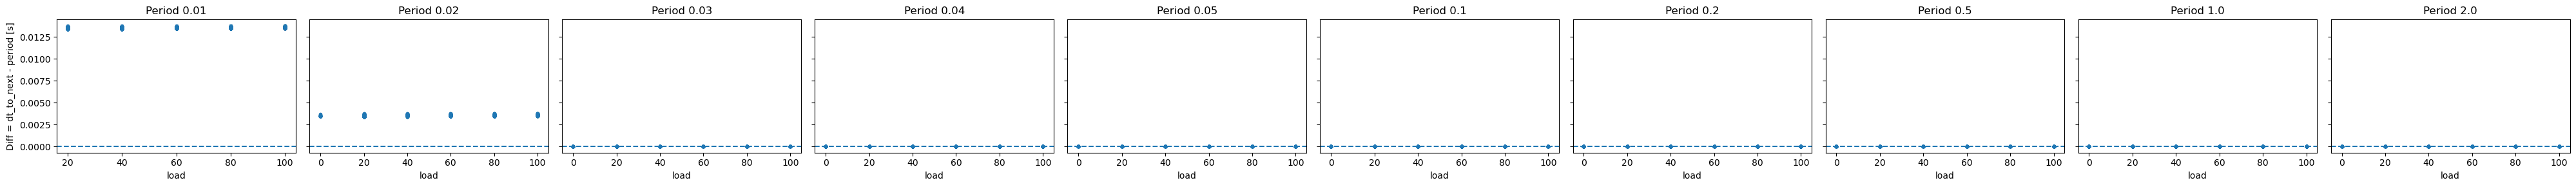

In [730]:
# display the time differences for each period according to the load

data= df_time_updated
periods = sorted(data["period"].unique())

fig, axes = plt.subplots(
    1, len(periods),
    figsize=(4 * len(periods), 3),
    sharey=True
)

if len(loads) == 1:
    axes = [axes]
    
for ax, period in zip(axes, periods):
    sub = data[data["period"] == period]

    # Optional: sort so periods appear nicely ordered on x
    sub = sub.sort_values("load")
    # Scatter of all points (many per period)
    ax.scatter(sub["load"], sub["diff"], alpha=0.3, s=8)
    ax.axhline(0, linestyle="--")

    ax.set_title(f"Period {period}")
    ax.set_xlabel("load")
    if ax is axes[0]:
        ax.set_ylabel("Diff = dt_to_next - period [s]")
plt.tight_layout()
plt.show()


<Axes: xlabel='period', ylabel='diff'>

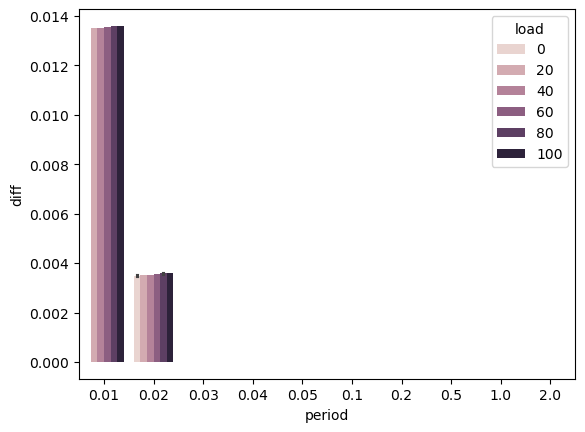

In [648]:
sns.barplot(data= df_time_updated, x='period', y='diff',hue='load')

In [650]:
df_time_updated.to_csv(output_directory+'energylogger_delays.csv')

In [652]:
df_time_updated.head(5)

,duration_s,diff,period,load,ID
0,0.780130,0.013496,0.01,40,8
1,0.803626,0.013485,0.01,40,8
2,0.827111,0.013470,0.01,40,8
3,0.850581,0.013590,0.01,40,8
4,0.874171,0.013472,0.01,40,8


In [654]:
# Energy influence from period and load

In [656]:
dfs.head(5)

,ID,load,period,filename,duration,3V7_WL_SW,3V3_SYS,1V8_SYS,DDR_VDD2,DDR_VDDQ,1V1_SYS,0V8_SW,VDD_CORE,3V3_DAC,3V3_ADC,0V8_AON,HDMI,freq_hz
0,0,40,0.02,pmic_log_0_1s_20251027_224819.csv,79.988601,0.059100,54.456447,22.768062,0.048884,0.002104,16.502727,18.543509,92.813460,0.045866,0.141180,0.218236,6.429707,50.0
1,1,0,0.05,pmic_log_0_1s_20251027_224819.csv,79.960689,0.018105,54.123822,21.686807,0.002278,0.000000,16.413142,18.434590,33.512278,0.048573,0.156587,0.214069,6.788918,20.0
2,2,0,0.01,pmic_log_0_1s_20251027_224819.csv,79.970523,0.024908,54.150361,21.716967,0.004669,0.000203,16.432699,18.441221,34.873584,0.046166,0.152944,0.214068,6.758719,100.0
3,3,80,0.02,pmic_log_0_1s_20251027_224819.csv,79.994015,0.038491,55.503239,22.817117,0.079725,0.002454,16.520007,18.629657,124.332259,0.045267,0.141383,0.220335,6.348336,50.0
4,4,80,0.10,pmic_log_0_1s_20251027_224819.csv,79.908986,0.040886,55.531174,22.845511,0.038387,0.000325,16.513766,18.594395,124.632223,0.046893,0.140930,0.221266,6.358555,10.0


In [658]:
## Influence by period 

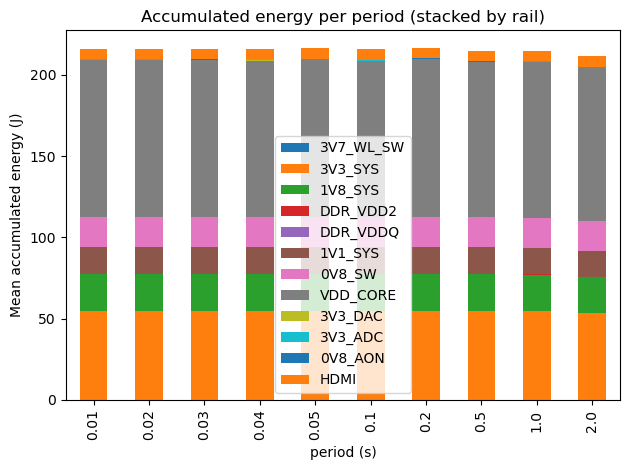

In [660]:
mean_by_period = (
    dfs.groupby("period", as_index=False)[energy_columns]
    .mean()
)

# print(mean_by_load)

import matplotlib.pyplot as plt

plot_df = mean_by_period.set_index("period")[energy_columns]

ax = plot_df.plot(kind="bar", stacked=True)
ax.set_xlabel("period (s)")
ax.set_ylabel("Mean accumulated energy (J)")
ax.set_title("Accumulated energy per period (stacked by rail)")
plt.tight_layout()
plt.show()

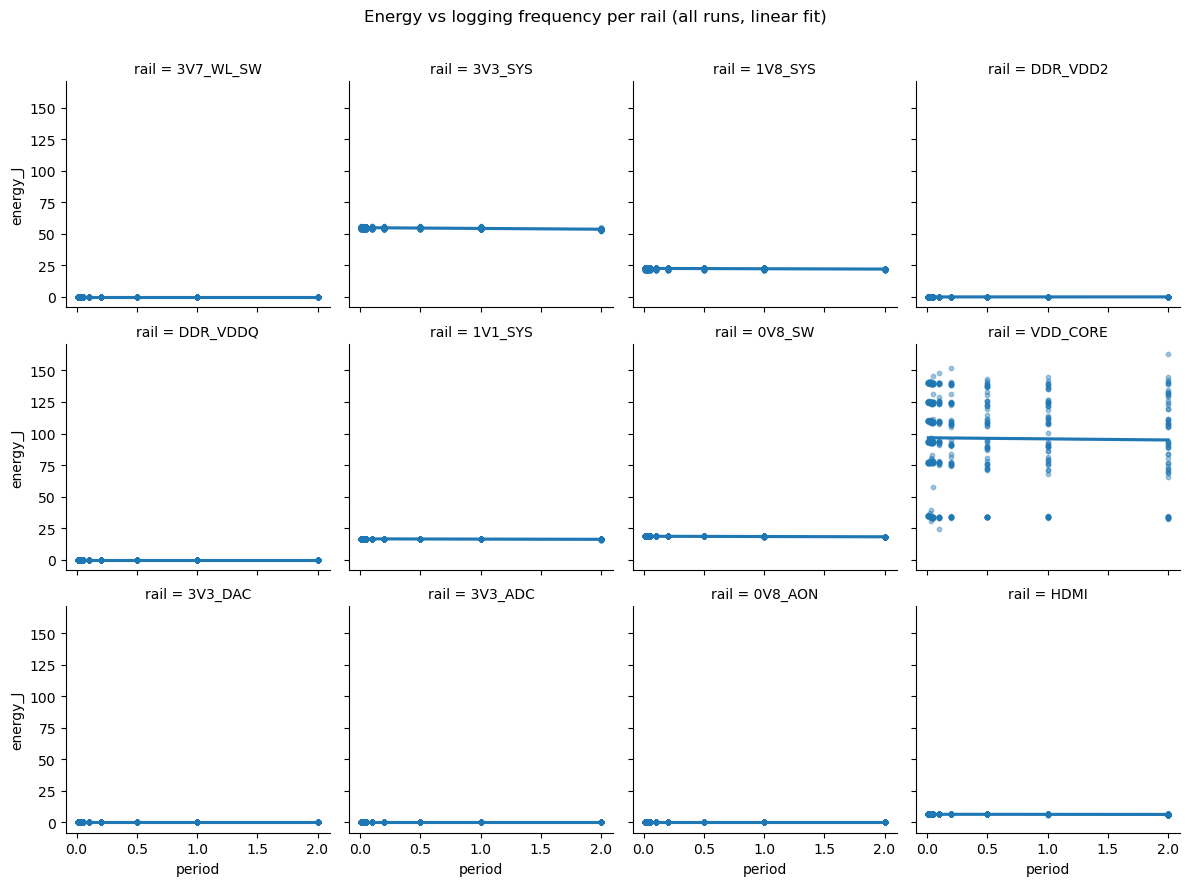

In [662]:

results = []
#dfs["freq_hz"] = 1.0 / dfs["period"]


df_melt = dfs.melt(
    id_vars=["period", "load"],
    value_vars=rail_cols,
    var_name="rail",
    value_name="energy_J")
    
sns.lmplot(
    data=df_melt,
    x="period",
    y="energy_J",
    col="rail",
    col_wrap=4,          # 4 plots per row; adjust as you like
    ci=None,
    height=3,
    scatter_kws={"s": 10, "alpha": 0.4}
)
plt.subplots_adjust(top=0.9)
plt.suptitle("Energy vs logging frequency per rail (all runs, linear fit)")
plt.show()

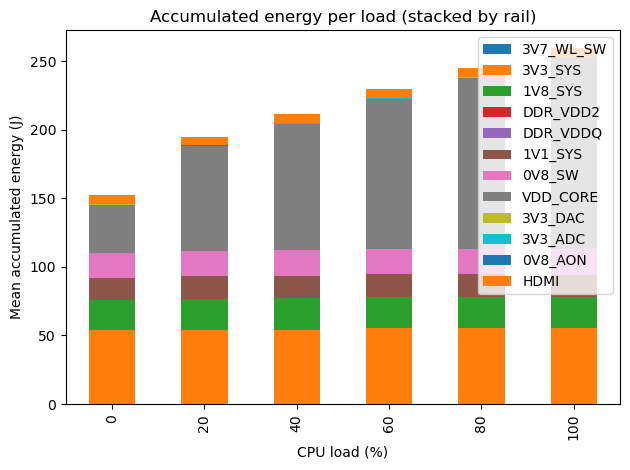

In [664]:

mean_by_load = (
    dfs.groupby("load", as_index=False)[energy_columns]
    .mean()
)

#print(mean_by_load)

import matplotlib.pyplot as plt

plot_df = mean_by_load.set_index("load")[energy_columns]

ax = plot_df.plot(kind="bar", stacked=True)
ax.set_xlabel("CPU load (%)")
ax.set_ylabel("Mean accumulated energy (J)")
ax.set_title("Accumulated energy per load (stacked by rail)")
plt.tight_layout()
plt.show()

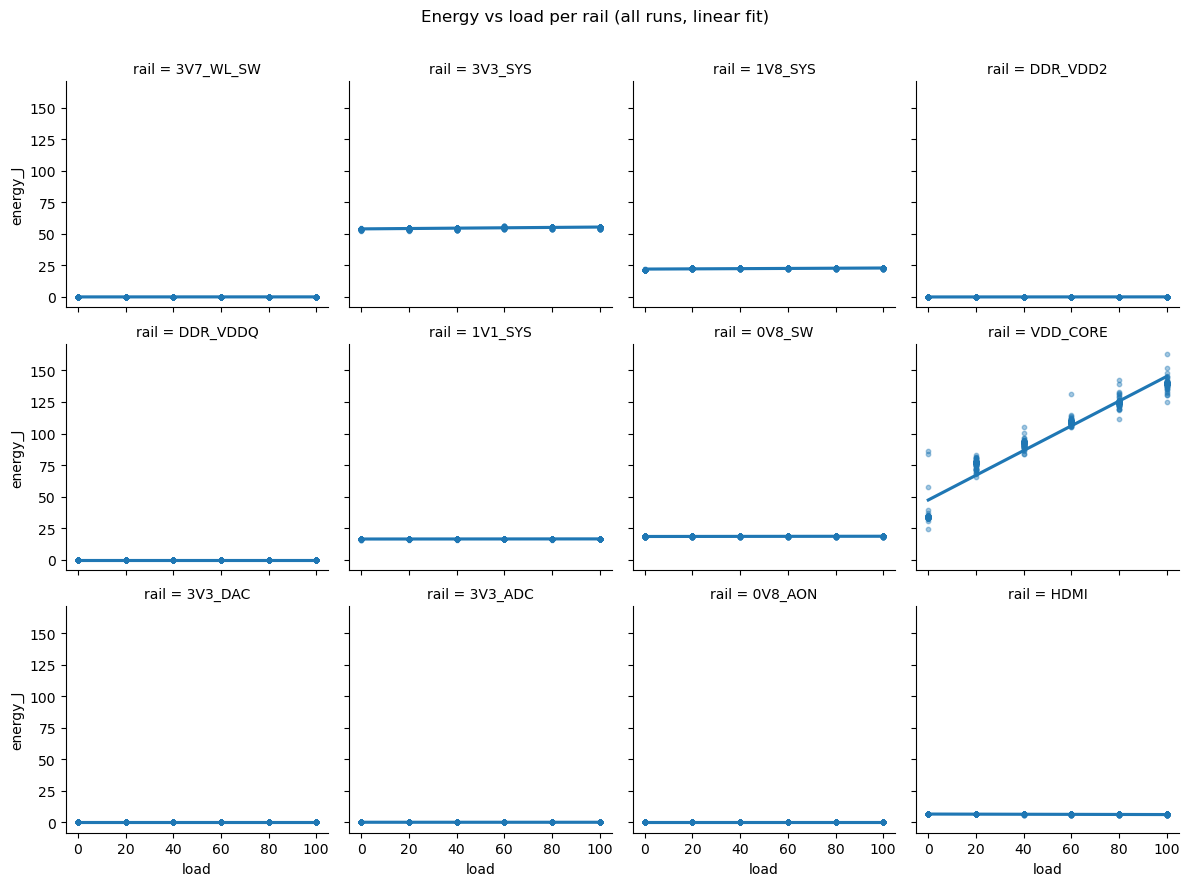

In [666]:
sns.lmplot(
    data=df_melt,
    x="load",
    y="energy_J",
    col="rail",
    col_wrap=4,          # 4 plots per row; adjust as you like
    ci=None,
    height=3,
    scatter_kws={"s": 10, "alpha": 0.4}
)
plt.subplots_adjust(top=0.9)
plt.suptitle("Energy vs load per rail (all runs, linear fit)")
plt.show()

# Overview of the impact of periods 

In the following correlation between energy and load and delay_factor we see that: 

- Real, load-dependent delays only happen at the two shortest periods (0.01 and 0.02 s).

- For ≥ 0.2 s (and practically ≥ 0.05 in your data), delay_factor is ~0 → no kernel / logger pressure.
Across almost all rails:

## There is a clear separation line for the periods:

The overloaded 10–20 ms sampling regime (0.01–0.02 s), where delay grows with load and many rails show high corr with both load and delay,
and the stable ≥30 ms regime, where delay is essentially noise and only load remains a substantive predictor.

### 0.01–0.02 s (overloaded regime)

corr with load: large in magnitude (often > 0.7, up to ~1.0).

corr with delay_factor: also large and very similar to corr(load).

That’s exactly where we know dt_s is far from period and depends on load.

### ≥ 0.03 s (stable timing)

corr with load: many rails stay high (strong or moderate), but not monotone in period.

corr with delay_factor: mostly small, noisy, or sign-flipping. Some values creep up to 0.1–0.3, but that doesn’t mean the effect is big – only that there’s some linear association in very tiny variations.


The rails that matter for CPU work (VDD_CORE, 0V8_SW, 0V8_AON, 1V1_SYS, 1V8_SYS, DDR_VDD2, 3V3_SYS) are:
strongly or moderately load-dependent across all periods, delay-dependent only when you are sampling too aggressively.

Several other rails (3V7_WL_SW, DDR_VDDQ, DAC/ADC, HDMI) behave differently (moderate positive or strong negative load correlations), which is useful evidence when you discuss “which parts of the SoC are actually responding to the CPU workload vs just following along”.

In [679]:
df_time_updated

,duration_s,diff,period,load,ID
0,0.780130,1.349600e-02,0.01,40,8
1,0.803626,1.348500e-02,0.01,40,8
2,0.827111,1.347000e-02,0.01,40,8
3,0.850581,1.359000e-02,0.01,40,8
4,0.874171,1.347200e-02,0.01,40,8
...,...,...,...,...,...
645201,68.000064,-2.000000e-06,2.00,0,578
645202,70.000062,0.000000e+00,2.00,0,578
645203,72.000062,-1.000000e-06,2.00,0,578
645204,74.000061,4.000000e-06,2.00,0,578


In [683]:
delay_stats = (
    df_time_updated
    .assign(dt_s=lambda d: d["period"] + d["diff"])  # reconstruct actual dt per sample
    .groupby(["ID", "load", "period"], as_index=False)
    .agg(
        mean_dt   = ("dt_s", "mean"),
        p99_dt    = ("dt_s", lambda x: x.quantile(0.99)),
        max_dt    = ("dt_s", "max"),
        duration_s=("duration_s", "max"),   # total elapsed time for that log
        n_samples = ("dt_s", "size")
    )
)

delay_stats["delay_factor"] = delay_stats["mean_dt"] - delay_stats["period"]
# which is also just mean(diff), since mean_dt = period + mean(diff)


In [732]:
merged = dfs.merge(
    delay_stats,
    on=["ID", "period", "load"],
    how="inner",
)

merged.head(5)

,ID,load,period,filename,duration,3V7_WL_SW,3V3_SYS,1V8_SYS,DDR_VDD2,DDR_VDDQ,...,3V3_DAC,3V3_ADC,0V8_AON,HDMI,mean_dt,p99_dt,max_dt,duration_s,n_samples,delay_factor
0,0,40,0.02,pmic_log_0_1s_20251027_224819.csv,79.988601,0.059100,54.456447,22.768062,0.048884,0.002104,...,0.045866,0.141180,0.218236,6.429707,0.023532,0.023647,0.023768,80.472238,3171,3.532165e-03
1,1,0,0.05,pmic_log_0_1s_20251027_224819.csv,79.960689,0.018105,54.123822,21.686807,0.002278,0.000000,...,0.048573,0.156587,0.214069,6.788918,0.050000,0.050001,0.050001,80.450055,1517,-2.307185e-08
2,3,80,0.02,pmic_log_0_1s_20251027_224819.csv,79.994015,0.038491,55.503239,22.817117,0.079725,0.002454,...,0.045267,0.141383,0.220335,6.348336,0.023568,0.023660,0.023740,80.476639,3297,3.568407e-03
3,4,80,0.10,pmic_log_0_1s_20251027_224819.csv,79.908986,0.040886,55.531174,22.845511,0.038387,0.000325,...,0.046893,0.140930,0.221266,6.358555,0.100000,0.100003,0.100003,80.400056,750,-2.933333e-08
4,5,0,0.10,pmic_log_0_1s_20251027_224819.csv,79.909447,0.022435,54.115087,21.707026,0.001619,0.000000,...,0.052164,0.160764,0.215163,6.797081,0.100000,0.100003,0.100003,80.400058,781,-8.962868e-09


In [685]:

periods = sorted(list(merged['period'].unique()))
for rail in power_columns:
    print(f'rail: {rail}')
    for period in periods:
        sub = merged[np.isclose(merged["period"], period)]
        corr_load = sub[rail].corr(sub["load"])
        corr_delay = sub[rail].corr(sub["delay_factor"])
        print(f'\tperiod: {period}, correlation load: {corr_load}, correlation delay: {corr_delay}')

rail: 3V7_WL_SW
	period: 0.01, correlation load: 0.061891221724975465, correlation delay: 0.01631587605146329
	period: 0.02, correlation load: 0.12776374441297894, correlation delay: 0.08447547013669449
	period: 0.03, correlation load: 0.4816604500438986, correlation delay: 0.06462878041812119
	period: 0.04, correlation load: 0.48305264194412817, correlation delay: -0.12380673821037066
	period: 0.05, correlation load: 0.4496284284419396, correlation delay: -0.03837081606559834
	period: 0.1, correlation load: 0.42818106856297805, correlation delay: 0.15052951414707394
	period: 0.2, correlation load: 0.26776594103814544, correlation delay: 0.19791180598068772
	period: 0.5, correlation load: 0.22578922101664756, correlation delay: -0.20513389639631807
	period: 1.0, correlation load: 0.2576670985818487, correlation delay: -0.10706174242131009
	period: 2.0, correlation load: 0.1619881754254063, correlation delay: 0.09280403078729234
rail: 3V3_SYS
	period: 0.01, correlation load: 0.743743658

In [521]:
print(mean_by_load)

   period  3V7_WL_SW    3V3_SYS    1V8_SYS  DDR_VDD2  DDR_VDDQ    1V1_SYS  \
0    0.01   0.053703  54.855970  22.606545  0.042657  0.001377  16.499405   
1    0.02   0.052469  54.862610  22.613166  0.044645  0.001428  16.500127   
2    0.03   0.055947  54.862900  22.606161  0.038302  0.001283  16.496232   
3    0.04   0.055823  54.851544  22.602887  0.036413  0.001114  16.494328   
4    0.05   0.055716  54.856094  22.600968  0.038422  0.000928  16.492832   
5    0.10   0.056619  54.854812  22.598073  0.030855  0.000487  16.492831   
6    0.20   0.054829  54.788446  22.568599  0.029314  0.000188  16.473290   
7    0.50   0.055195  54.863326  22.587549  0.036121  0.000193  16.493531   
8    1.00   0.063199  54.533344  22.450314  0.052318  0.000277  16.397180   
9    2.00   0.060746  53.531916  22.039091  0.053079  0.000390  16.101113   

      0V8_SW   VDD_CORE   3V3_DAC   3V3_ADC   0V8_AON      HDMI  
0  18.561148  96.733712  0.044969  0.144108  0.218345  6.445955  
1  18.562433  96.730

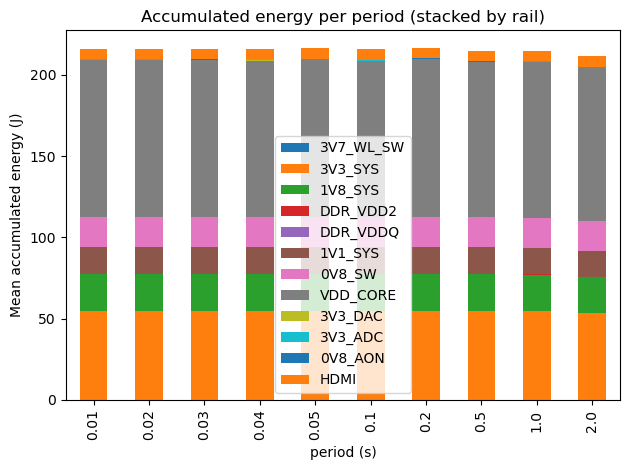

In [525]:
df_period = mean_by_period.copy()
df_period["freq_hz"] = 1.0 / df_period["period"]

# all rails = all columns except 'period' and 'freq_hz'
rail_cols = [c for c in df_period.columns if c not in ("period", "freq_hz")]
rail_cols

['3V7_WL_SW',
 '3V3_SYS',
 '1V8_SYS',
 'DDR_VDD2',
 'DDR_VDDQ',
 '1V1_SYS',
 '0V8_SW',
 'VDD_CORE',
 '3V3_DAC',
 '3V3_ADC',
 '0V8_AON',
 'HDMI']

In [529]:
results = []

x = df_period["freq_hz"].values
x_mean = x.mean()
x_var = ((x - x_mean)**2).sum()

for rail in rail_cols:
    y = df_period[rail].values
    y_mean = y.mean()
    # slope via least squares (equivalent to np.polyfit degree 1)
    cov_xy = ((x - x_mean) * (y - y_mean)).sum()
    slope = cov_xy / x_var
    # simple correlation coefficient (optional)
    corr = cov_xy / np.sqrt(x_var * ((y - y_mean)**2).sum())
    results.append({"rail": rail, "slope_J_per_Hz": slope, "corr": corr})

slopes = pd.DataFrame(results).sort_values("slope_J_per_Hz", ascending=False)
slopes



,rail,slope_J_per_Hz,corr
7,VDD_CORE,0.009756,0.417022
1,3V3_SYS,0.004735,0.351535
2,1V8_SYS,0.002181,0.380005
6,0V8_SW,0.001733,0.367635
5,1V1_SYS,0.001478,0.368694
11,HDMI,0.000228,0.154577
3,DDR_VDD2,0.000015,0.059583
4,DDR_VDDQ,0.000013,0.811123
10,0V8_AON,0.000012,0.226316
9,3V3_ADC,-0.000020,-0.318985


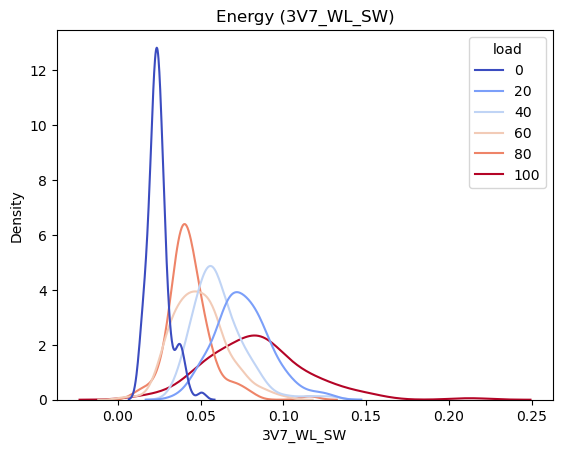

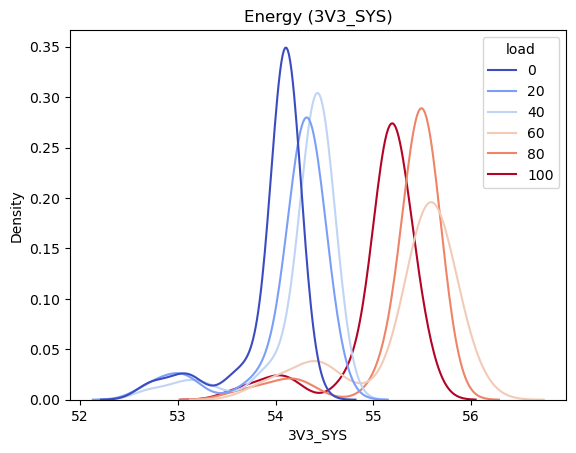

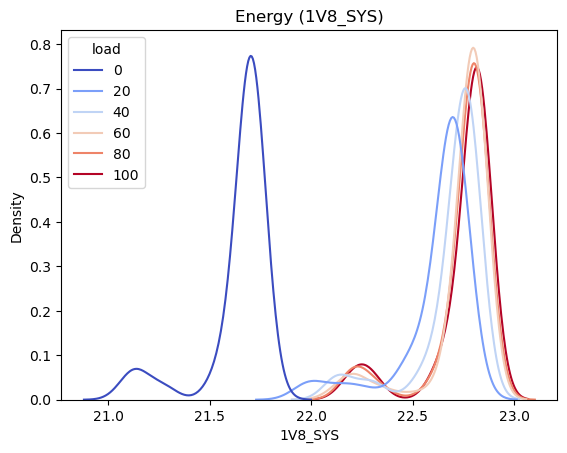

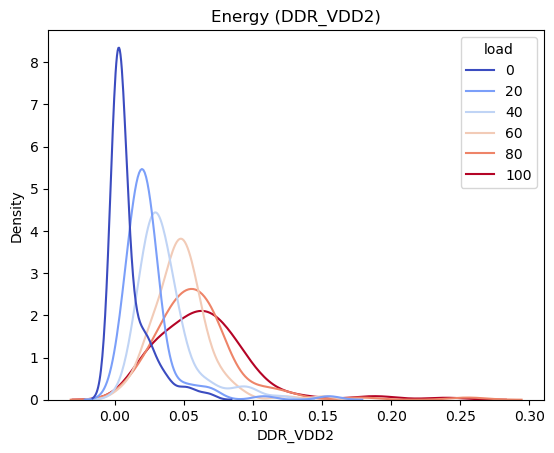

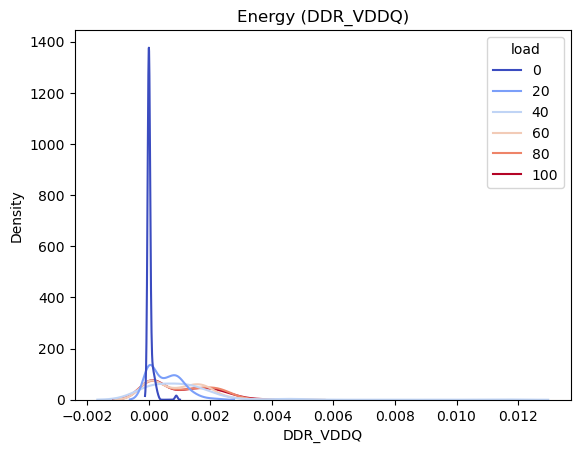

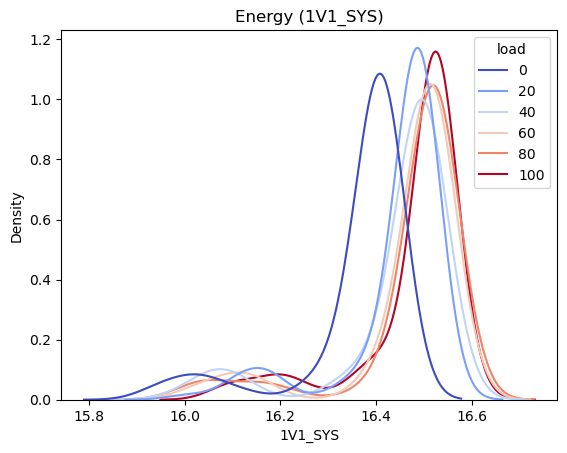

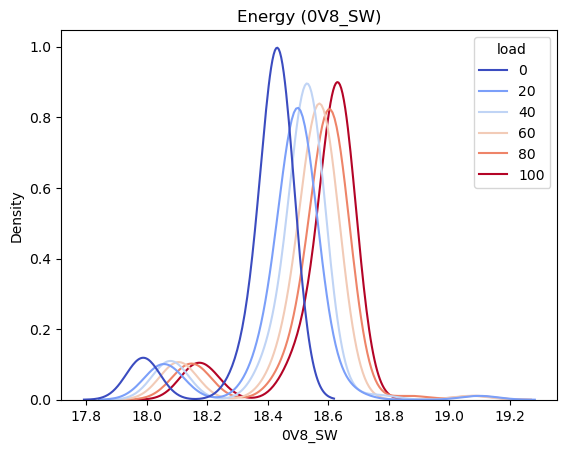

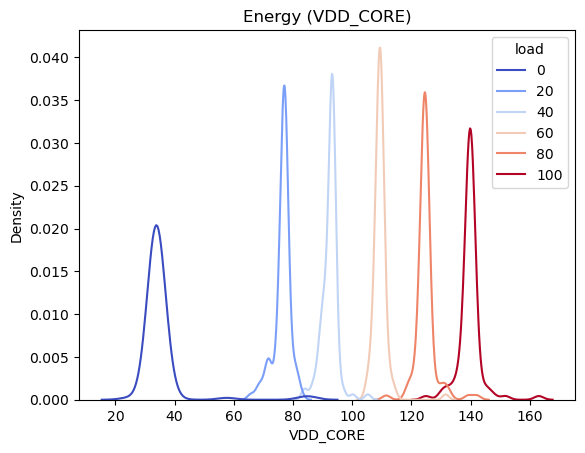

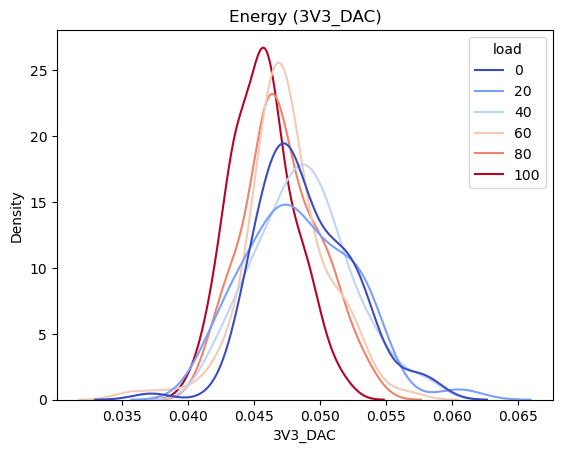

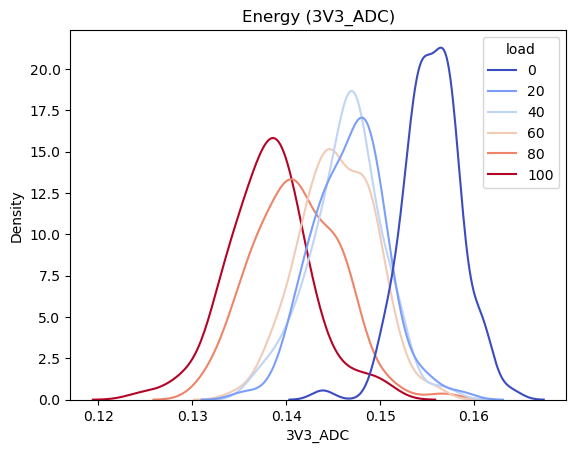

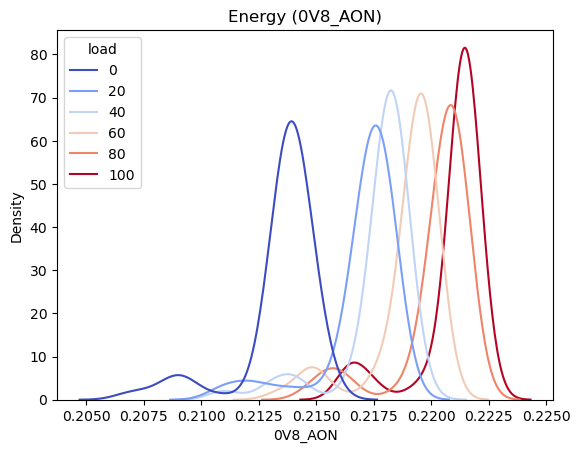

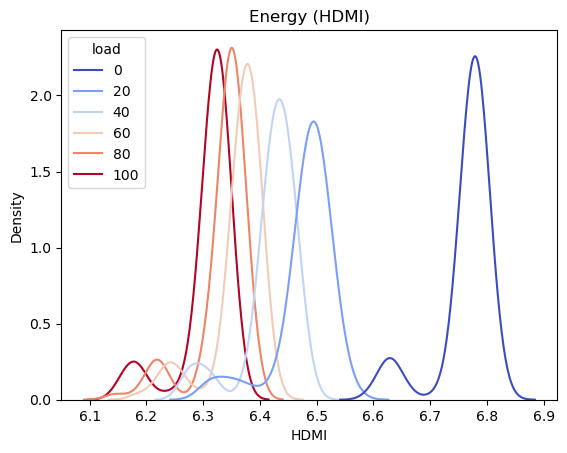

In [501]:
for column in power_columns: 
    sns.kdeplot(data=dfs,x=column,hue='load',palette='coolwarm')
    plt.title(f"Energy ({column})") 
    plt.show()

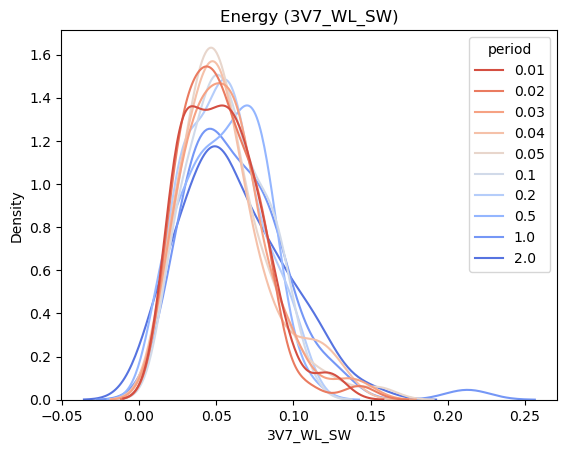

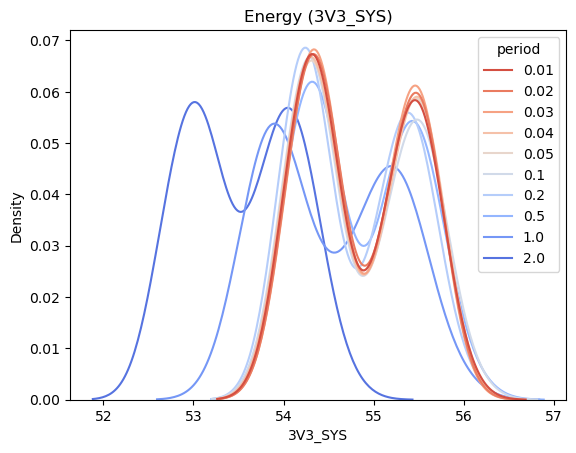

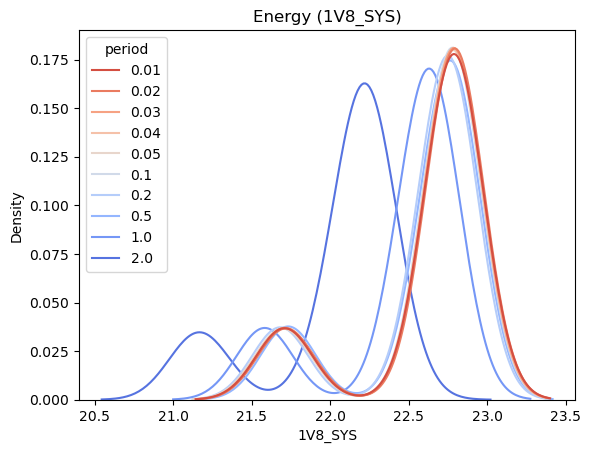

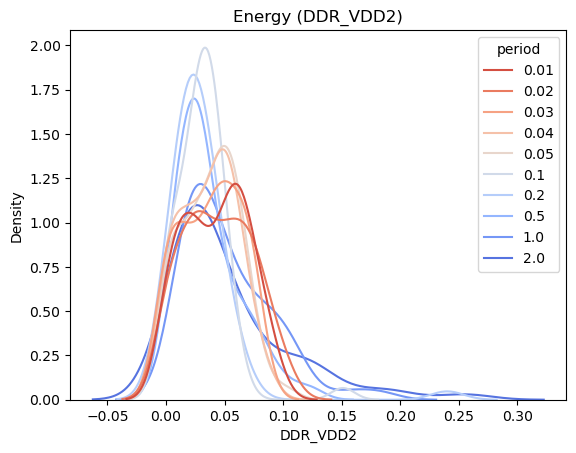

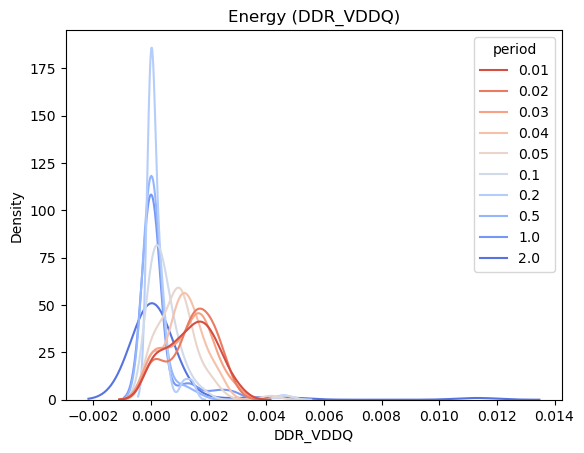

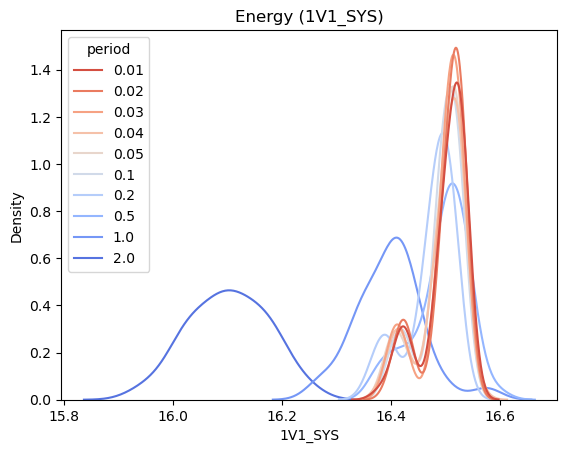

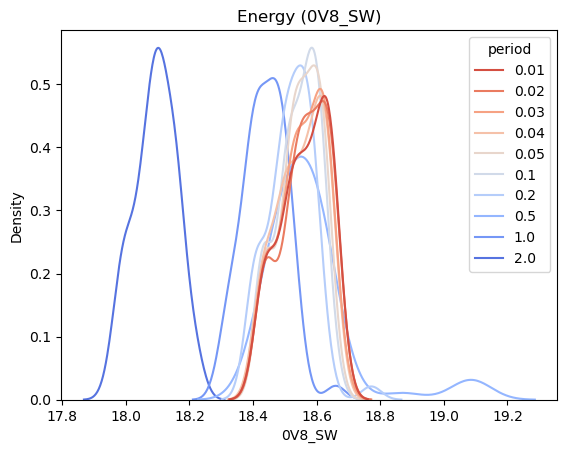

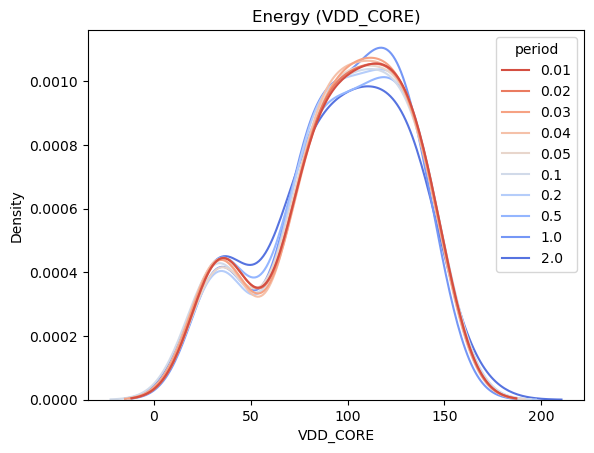

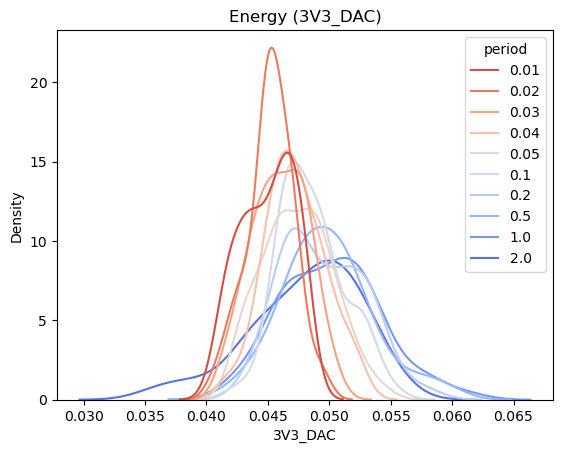

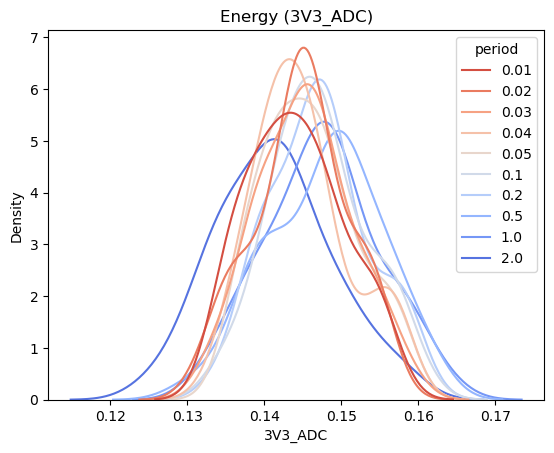

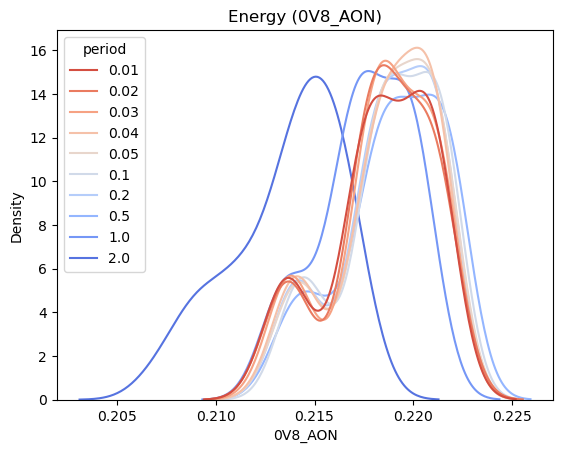

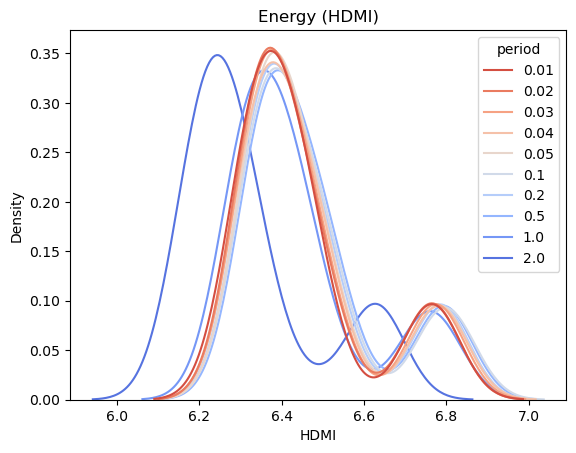

In [503]:
palette_reverse = sns.color_palette("coolwarm",n_colors=10)
palette_reverse.reverse()

for column in power_columns: 
    sns.kdeplot(data=dfs,x=column,hue='period',palette=palette_reverse)
    plt.title(f"Energy ({column})") 
    plt.show()

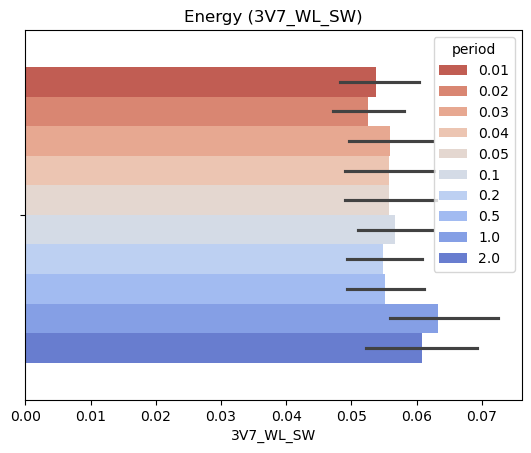

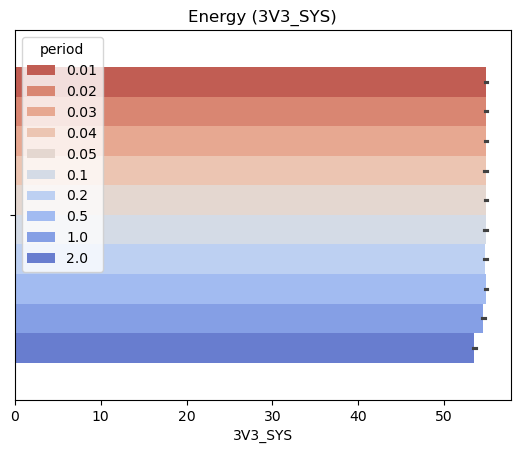

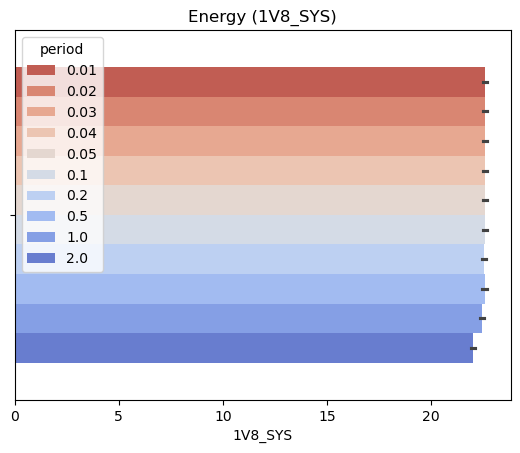

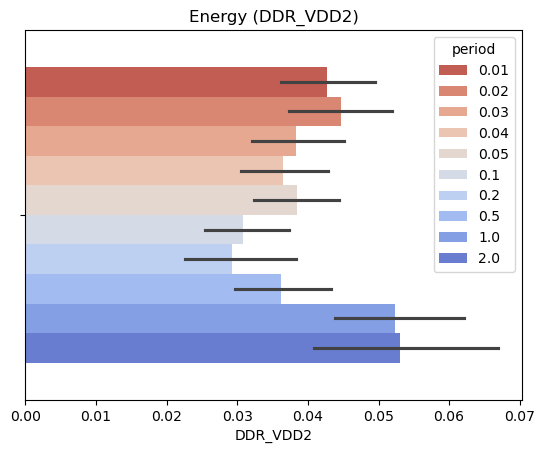

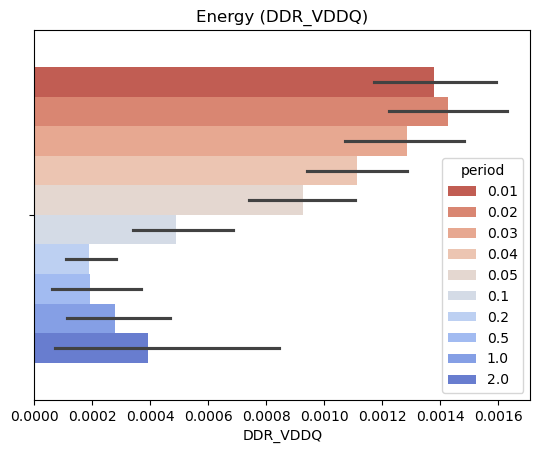

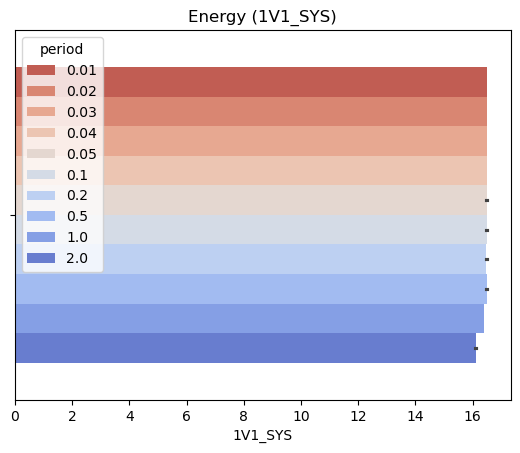

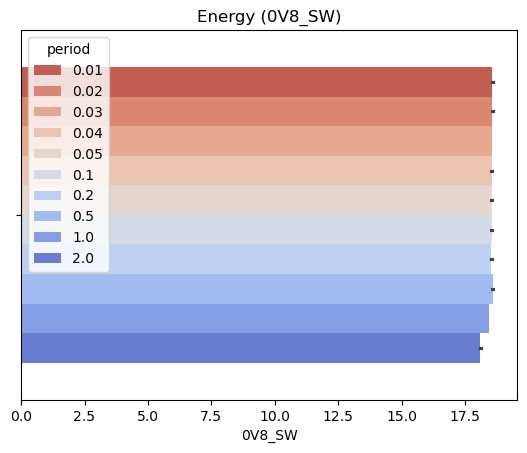

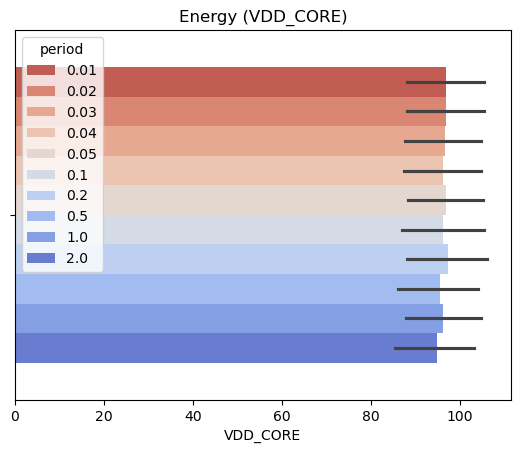

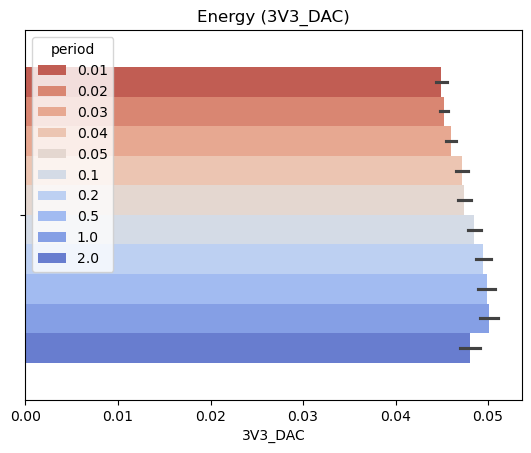

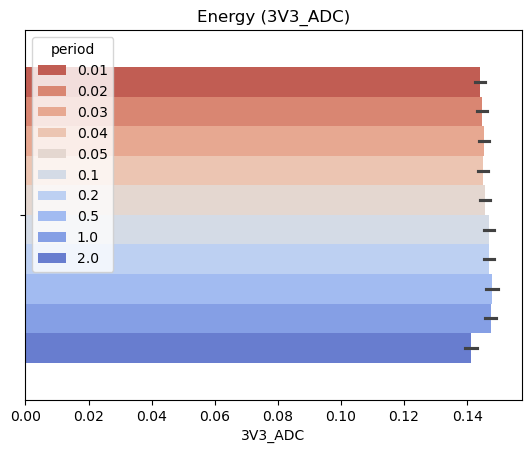

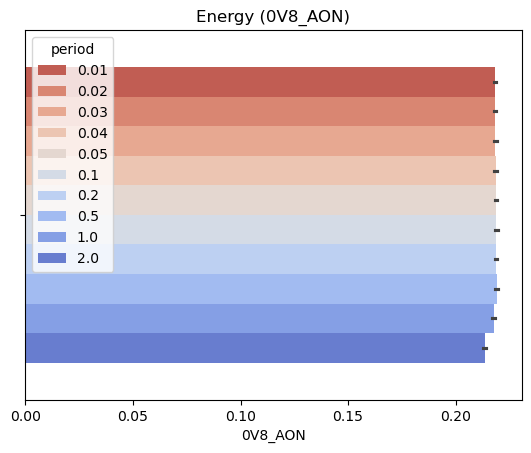

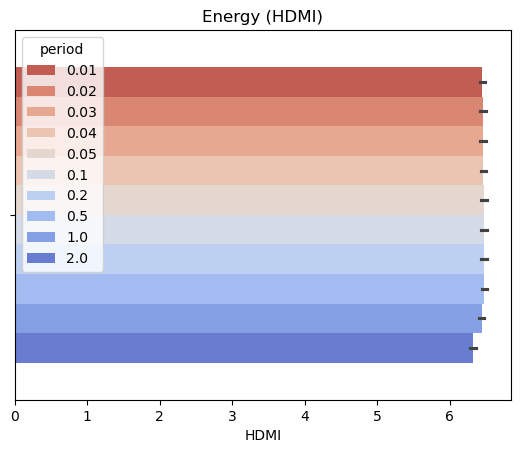

In [505]:
palette_reverse = sns.color_palette("coolwarm",n_colors=10)
palette_reverse.reverse()

for column in power_columns: 
    sns.barplot(data=dfs,x=column,hue='period',palette=palette_reverse)
    plt.title(f"Energy ({column})") 
    plt.show()

In [471]:
dfs.to_csv(output_directory+"EnergyLogger_summarized.csv")

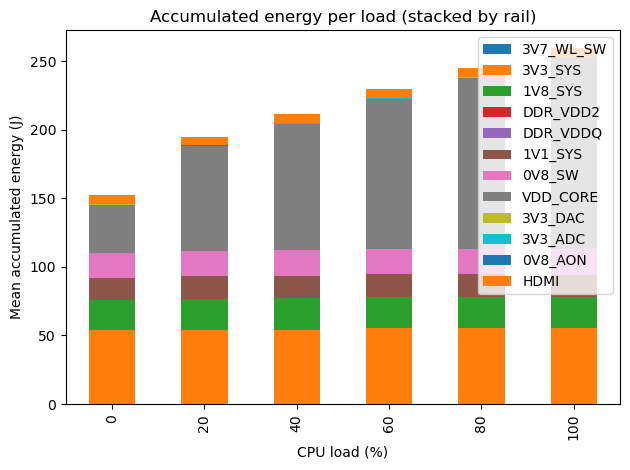

In [ ]:
mean_by_load.index(

In [ ]:
df.plot(kind='bar', stacked=True, color=['red', 'skyblue', 'green'])